In [1]:
import pandas as pd
import numpy as np
import os


os.chdir("C:/Users/cuent/En-Peu/notebooks/")
print(os.getcwd())


C:\Users\cuent\En-Peu\notebooks


In [2]:
# Cambiar al directorio padre
os.chdir("..")
parent_directory = os.getcwd()

# os.path.join() maneja correctamente las barras de ruta para diferentes SO (Windows, Linux, macOS)
file_path = os.path.join(parent_directory, 'data', 'data_fin.csv')

# Cargar el archivo CSV
data = pd.read_csv(file_path)


# Verificar la estructura del DataFrame (equivalente a str(data) en R)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64345 entries, 0 to 64344
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   POINT_X  64345 non-null  float64
 1   POINT_Y  64345 non-null  float64
 2   PLA      64345 non-null  float64
 3   A        64345 non-null  float64
 4   AC       64345 non-null  float64
 5   CIB      64345 non-null  float64
 6   CICCB    64345 non-null  float64
 7   DBB      64345 non-null  float64
 8   DOB      64345 non-null  float64
 9   P        64345 non-null  float64
 10  CUS_1    64345 non-null  float64
 11  CUS_2    64345 non-null  float64
 12  CUS_3    64345 non-null  float64
 13  CUS_4    64345 non-null  float64
 14  CUS_5    64345 non-null  float64
 15  OC_1     64345 non-null  float64
 16  OC_2     64345 non-null  float64
 17  OC_3     64345 non-null  float64
 18  OC_4     64345 non-null  float64
dtypes: float64(19)
memory usage: 9.3 MB
None


In [38]:
################ LOAD SCALER ################
# Queremos ver los resultados desnormalizados. 
# Cargar el scaler guardado en el notebook anterior
import joblib # To save/load models and for parallel processing

scaler_path = os.path.join(parent_directory, 'data','min_max_scaler.pkl')
loaded_scaler = joblib.load(scaler_path)

min_pla = loaded_scaler.data_min_[0]
range_pla = loaded_scaler.data_range_[0]

In [4]:
from sklearn.model_selection import train_test_split

# 1. Definir las características (X) y la variable objetivo (y)
# X serán todas las columnas excepto 'PLA' y las coordenadas
coordinates = data[['POINT_X', 'POINT_Y']].copy()
X = data.drop(columns=['PLA', 'POINT_X','POINT_Y'])
# X = data.drop(columns=['PLA', 'POINT_X','POINT_Y','DOB'])
# y será la columna 'PLA'
y = data['PLA']

# 2. Dividir los datos en conjuntos de entrenamiento y prueba
# test_size=0.20 significa 20% para prueba, por lo tanto 80% para entrenamiento
# random_state=12345 asegura que la división sea reproducible
# shuffle=True (por defecto) asegura que los datos se mezclen antes de la división
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12345
)

# Usa los índices de X_test_scaled para seleccionar las coordenadas originales
coordinates_test = coordinates.loc[X_test.index].copy()

# 4. Mostrar las formas de los nuevos DataFrames/Series para verificar
print("\nForma de X_train (características de entrenamiento):", X_train.shape)
print("Forma de y_train (etiquetas de entrenamiento):", y_train.shape)
print("Forma de X_test (características de prueba):", X_test.shape)
print("Forma de y_test (etiquetas de prueba):", y_test.shape)

print("\nPrimeras filas de X_train:")
print(X_train.head())
print("\nPrimeras filas de y_train:")
print(y_train.head())


Forma de X_train (características de entrenamiento): (51476, 16)
Forma de y_train (etiquetas de entrenamiento): (51476,)
Forma de X_test (características de prueba): (12869, 16)
Forma de y_test (etiquetas de prueba): (12869,)

Primeras filas de X_train:
              A        AC       CIB     CICCB       DBB       DOB         P  \
48196  0.634369  0.324476  0.101781  0.291697  0.484058  0.605235  0.036417   
31410  0.721612  0.027246  0.778726  0.541413  0.138255  0.208782  0.020722   
23835  0.534206  1.000000  0.043877  0.236189  0.285055  0.631355  0.000000   
53962  0.584288  0.324476  0.401558  0.193533  0.679098  0.738164  0.058812   
45212  0.805616  1.000000  0.816241  0.443402  0.213456  0.300115  0.032442   

       CUS_1  CUS_2  CUS_3  CUS_4  CUS_5  OC_1  OC_2  OC_3  OC_4  
48196    0.0    0.0    0.0    0.0    1.0   1.0   0.0   0.0   0.0  
31410    0.0    1.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
23835    1.0    0.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
53

In [ ]:
###################################################################
###################################################################
# OJO, NO EJECUTAR ESTE, ES SOLO PARA ESCOGER LAS VAR IMPORTANTES #
###################################################################
###################################################################
##########  PARA NUEVO MODELO CON VARIABLES IMPORTANTES  ##########

# os.path.join() maneja correctamente las barras de ruta para diferentes SO (Windows, Linux, macOS)
file_path = os.path.join(parent_directory, 'data', 'data_fin_IMPORTANTES.csv')

# Cargar el archivo CSV
data = pd.read_csv(file_path)


# Verificar la estructura del DataFrame (equivalente a str(data) en R)
print(data.info())
from sklearn.model_selection import train_test_split

# 1. Definir las características (X) y la variable objetivo (y)
# X serán todas las columnas excepto 'PLA' y las coordenadas
# importantes:CIB, DOB, DBB, CICCB, A y P
coordinates = data[['POINT_X', 'POINT_Y']].copy()

X = data.drop(columns=['PLA', 'POINT_X','POINT_Y', 'CUS', 'OC', 'AC'])
# y será la columna 'PLA'
y = data['PLA']

# 2. Dividir los datos en conjuntos de entrenamiento y prueba
# test_size=0.20 significa 20% para prueba, por lo tanto 80% para entrenamiento
# random_state=12345 asegura que la división sea reproducible
# shuffle=True (por defecto) asegura que los datos se mezclen antes de la división
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12345
)

# Usa los índices de X_test_scaled para seleccionar las coordenadas originales
coordinates_test = coordinates.loc[X_test.index].copy()

# 4. Mostrar las formas de los nuevos DataFrames/Series para verificar
print("\nForma de X_train (características de entrenamiento):", X_train.shape)
print("Forma de y_train (etiquetas de entrenamiento):", y_train.shape)
print("Forma de X_test (características de prueba):", X_test.shape)
print("Forma de y_test (etiquetas de prueba):", y_test.shape)

print("\nPrimeras filas de X_train:")
print(X_train.head())
print("\nPrimeras filas de y_train:")
print(y_train.head())

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV # For cross-validation and hyperparameter tuning
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # For evaluation metrics
import joblib # To save/load models and for parallel processing

# --- 1. Paralelización (Gestionado por scikit-learn con 'n_jobs') ---
# En Python con scikit-learn, la paralelización se maneja con el parámetro `n_jobs`.
# n_jobs = -1 significa usar todos los núcleos disponibles.
# n_jobs = -2 significa usar todos los núcleos excepto 1.
n_cores = joblib.cpu_count() - 1
print(f"\nDetectados {joblib.cpu_count()} núcleos, usando {n_cores} para paralelización.")


# --- 2. Control de validación cruzada (GridSearchCV) ---
# 'trainControl' de caret se traduce a GridSearchCV de scikit-learn
# metric = "RMSE" en R es 'neg_root_mean_squared_error' en scikit-learn (para minimizar)
# Ojo: GridSearchCV siempre intenta MAXIMIZAR la métrica, por eso es 'negativo RMSE'.
scoring_metric = 'neg_root_mean_squared_error' # Minimizar RMSE -> Maximizar -RMSE



Detectados 20 núcleos, usando 19 para paralelización.


In [22]:
#################################
### Random Forest con validación cruzada espacial
#################################

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# --- 1) Definición del modelo y la grilla de hiperparámetros ---
grid_rf = {
    'n_estimators': [500],             # ntree = 500
    'max_features': [2, 5, 10],        # mtry en R
    'random_state': [42]               # reproducibilidad
}
model_rf_base = RandomForestRegressor()



from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold

def generar_grupos(X, coordinates, n_groups=5):
    """
    Genera grupos para validación cruzada:
    - Si X tiene 'municipio_id', se usa directamente.
    - Si no, crea clusters espaciales a partir de las coordenadas.
    """
    if "municipio_id" in X.columns:
        groups = X["municipio_id"].values
        print("Usando municipio_id como grupos de CV.")
    else:
        print(f"No se encontró municipio_id, generando {n_groups} clusters espaciales con KMeans...")
        kmeans = KMeans(n_clusters=n_groups, random_state=42)
        groups = kmeans.fit_predict(coordinates)
    return groups

# --- Ejemplo en tu flujo actual ---
# X, y, coordinates ya están definidos
groups = generar_grupos(X, coordinates, n_groups=10)


# Extraer grupos para train/test
groups_train = groups[X_train.index]
groups_test = groups[X_test.index]

# Configurar GroupKFold
cv_strategy = GroupKFold(n_splits=10)


# Usar en tu GridSearchCV:
modelo_rf_grid = GridSearchCV(
    estimator=model_rf_base,
    param_grid=grid_rf,
    cv=cv_strategy,
    scoring=scoring_metric,
    verbose=1,
    n_jobs=n_cores,
    return_train_score=False
)

# Entrenamiento con grupos
# --- 3) Entrenar el modelo ---
print("\nIniciando entrenamiento del modelo Random Forest con GridSearchCV...")
modelo_rf_grid.fit(X_train, y_train, groups=groups_train)

print("\nMejores hiperparámetros Random Forest:", modelo_rf_grid.best_params_)
print(f"Mejor RMSE de validación: {-modelo_rf_grid.best_score_:.4f}")

# --- 4) Evaluación en test ---
predicciones_rf = modelo_rf_grid.predict(X_test)

# Desnormalizar (usa tu scaler/min-max guardado)
predicciones_rf_desnormalized = predicciones_rf * range_pla + min_pla
y_test_desnormalized = y_test * range_pla + min_pla

rmse_desnormalized_rf = np.sqrt(mean_squared_error(y_test_desnormalized, predicciones_rf_desnormalized))
mae_desnormalized_rf = mean_absolute_error(y_test_desnormalized, predicciones_rf_desnormalized)
r2_desnormalized_rf = r2_score(y_test_desnormalized, predicciones_rf_desnormalized)

print("\n--- Métricas en escala original (desnormalizada) ---")
print(f"RMSE: {rmse_desnormalized_rf:.4f}")
print(f"MAE: {mae_desnormalized_rf:.4f}")
print(f"R²: {r2_desnormalized_rf:.4f}")


#################################
### 5) Evaluación en nuevos municipios
#################################

def evaluar_nuevo_municipio(csv_path, scaler, model, range_pla, min_pla):
    """
    Evalúa el modelo entrenado en un nuevo municipio.
    csv_path: ruta al CSV con coordenadas, variables predictoras y PLA observado.
    scaler: el mismo usado para normalizar durante el entrenamiento.
    model: modelo entrenado (GridSearchCV).
    range_pla, min_pla: parámetros de desnormalización.
    """

    # --- Cargar datos ---
    df = pd.read_csv(csv_path)

    # Separar X e y
    if "PLA" not in df.columns:
        raise ValueError("El CSV debe contener la variable respuesta 'PLA'")
    X_new = df.drop(columns=["PLA"])
    y_new = df["PLA"]

    # Normalizar con scaler entrenado
    X_new_scaled = pd.DataFrame(scaler.transform(X_new), columns=X_new.columns)

    # Predicciones
    y_pred_norm = model.predict(X_new_scaled)

    # Desnormalizar
    y_pred = y_pred_norm * range_pla + min_pla

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_new, y_pred))
    mae = mean_absolute_error(y_new, y_pred)
    r2 = r2_score(y_new, y_pred)

    print(f"\n--- Evaluación en nuevo municipio ({csv_path}) ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

    return y_new, y_pred

# Ejemplo de uso:
# y_obs, y_pred = evaluar_nuevo_municipio("nuevo_municipio.csv", scaler, modelo_rf_grid, range_pla, min_pla)


No se encontró municipio_id, generando 10 clusters espaciales con KMeans...

Iniciando entrenamiento del modelo Random Forest con GridSearchCV...
Fitting 10 folds for each of 3 candidates, totalling 30 fits

Mejores hiperparámetros Random Forest: {'max_features': 10, 'n_estimators': 500, 'random_state': 42}
Mejor RMSE de validación: 0.0514

--- Métricas en escala original (desnormalizada) ---
RMSE: 0.1267
MAE: 0.0456
R²: 0.9621


No se encontró municipio_id, generando 5 clusters espaciales con KMeans...

Iniciando entrenamiento del modelo Random Forest con GridSearchCV...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Mejores hiperparámetros Random Forest: {'max_features': 5, 'n_estimators': 500, 'random_state': 42}
Mejor RMSE de validación: 0.0593

--- Métricas en escala original (desnormalizada) ---
RMSE: 0.1329
MAE: 0.0500
R²: 0.9583


No se encontró municipio_id, generando 8 clusters espaciales con KMeans...

Iniciando entrenamiento del modelo Random Forest con GridSearchCV...
Fitting 8 folds for each of 3 candidates, totalling 24 fits

Mejores hiperparámetros Random Forest: {'max_features': 5, 'n_estimators': 500, 'random_state': 42}
Mejor RMSE de validación: 0.0508

--- Métricas en escala original (desnormalizada) ---
RMSE: 0.1329
MAE: 0.0500
R²: 0.9583

Representación de grupos para validación espacial


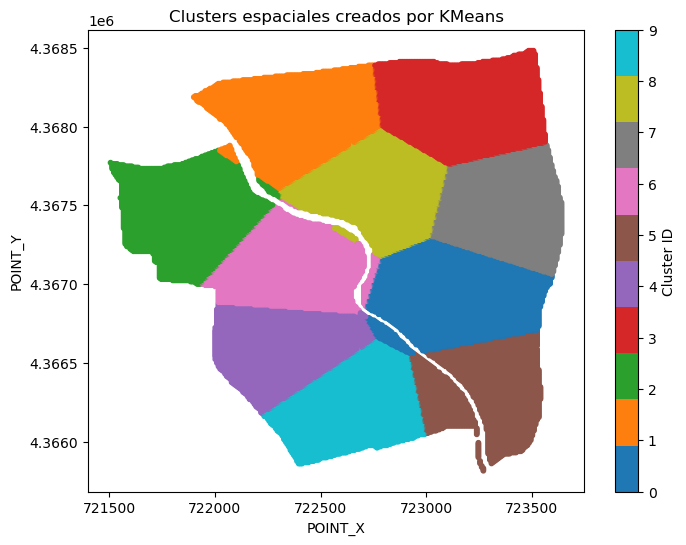

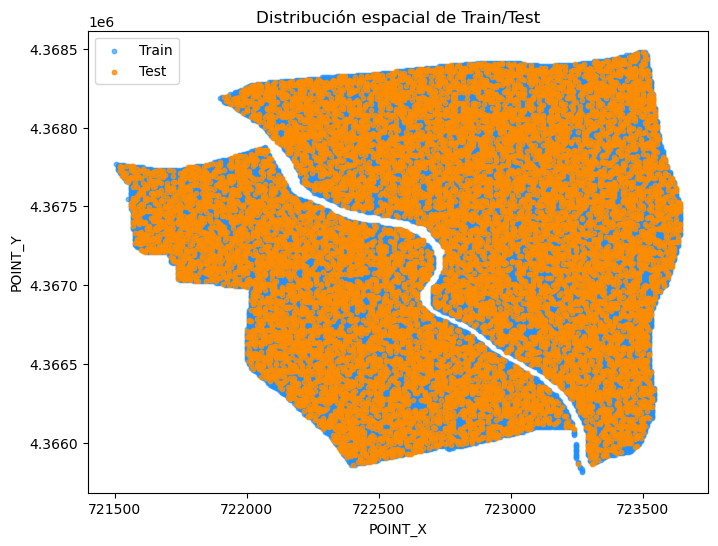

In [23]:
import matplotlib.pyplot as plt

print('Representación de grupos para validación espacial')
#### --- Visualizar los clusters espaciales creados por KMeans ---
plt.figure(figsize=(8, 6))
plt.scatter(coordinates["POINT_X"], coordinates["POINT_Y"], c=groups, cmap='tab10', s=10)
plt.title("Clusters espaciales creados por KMeans")
plt.xlabel("POINT_X")
plt.ylabel("POINT_Y")
plt.colorbar(label="Cluster ID")
plt.show()

#### --- Visualizar train/test ---
plt.figure(figsize=(8, 6))
plt.scatter(coordinates.loc[X_train.index, "POINT_X"],
            coordinates.loc[X_train.index, "POINT_Y"],
            color="dodgerblue", s=10, label="Train", alpha=0.6)
plt.scatter(coordinates.loc[X_test.index, "POINT_X"],
            coordinates.loc[X_test.index, "POINT_Y"],
            color="darkorange", s=10, label="Test", alpha=0.8)
plt.title("Distribución espacial de Train/Test")
plt.xlabel("POINT_X")
plt.ylabel("POINT_Y")
plt.legend()
plt.show()

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
import numpy as np

# --- Crear el modelo base ---
rf = RandomForestRegressor(
    n_estimators=500,
    max_features=5,
    #min_samples_leaf=[1, 5, 10],
    random_state=42,
    n_jobs=-1
)

# --- Ejemplo en tu flujo actual ---
# X, y, coordinates ya están definidos
groups = generar_grupos(X, coordinates, n_groups=5)

# --- Definir validación cruzada espacial ---
cv = GroupKFold(n_splits=5)

# --- Inicializar listas para métricas ---
rmse_folds, mae_folds, r2_folds = [], [], []

# --- Validación cruzada manual ---
fold = 1
for train_idx, test_idx in cv.split(X, y, groups=groups):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)

    rmse_folds.append(rmse)
    mae_folds.append(mae)
    r2_folds.append(r2)

    print(f"Fold {fold}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    fold += 1

# --- Resumen general ---
print("\n--- Promedio de métricas en validación cruzada espacial ---")
print(f"RMSE medio: {np.mean(rmse_folds):.4f} ± {np.std(rmse_folds):.4f}")
print(f"MAE medio: {np.mean(mae_folds):.4f} ± {np.std(mae_folds):.4f}")
print(f"R² medio: {np.mean(r2_folds):.4f} ± {np.std(r2_folds):.4f}")

No se encontró municipio_id, generando 5 clusters espaciales con KMeans...
Fold 1: RMSE=0.0460, MAE=0.0331, R²=-0.5125
Fold 2: RMSE=0.0653, MAE=0.0453, R²=-0.1712
Fold 3: RMSE=0.0554, MAE=0.0440, R²=0.3023
Fold 4: RMSE=0.0601, MAE=0.0497, R²=-0.5458
Fold 5: RMSE=0.0722, MAE=0.0504, R²=0.1658

--- Promedio de métricas en validación cruzada espacial ---
RMSE medio: 0.0598 ± 0.0089
MAE medio: 0.0445 ± 0.0062
R² medio: -0.1523 ± 0.3443


In [39]:
############ PLA CON EMBEDDINGS ##################

# os.path.join() maneja correctamente las barras de ruta para diferentes SO (Windows, Linux, macOS)
file_path = os.path.join(parent_directory, 'data', "data_con_embeddings.csv")

# Cargar el archivo CSV
data = pd.read_csv(file_path)


# Seleccionar solo columnas de embeddings
emb_cols = [col for col in data.columns if col.startswith('emb_')]
emb_data = data[emb_cols]

# Estadísticas descriptivas
print(emb_data.describe())
print(emb_data.head(5))


from sklearn.model_selection import train_test_split

# 1. Definir las características (X) y la variable objetivo (y)
# X serán todas las columnas excepto 'PLA' y las coordenadas
coordinates = data[['POINT_X', 'POINT_Y']].copy()
lonlat = data[['lon', 'lat']].copy()
#X = data.drop(columns=['PLA', 'POINT_X','POINT_Y', 'lon', 'lat'])
# para tener solo embeddings:
X = emb_data

# y será la columna 'PLA'
y = data['PLA']

# 2. Dividir los datos en conjuntos de entrenamiento y prueba
# test_size=0.20 significa 20% para prueba, por lo tanto 80% para entrenamiento
# random_state=12345 asegura que la división sea reproducible
# shuffle=True (por defecto) asegura que los datos se mezclen antes de la división
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12345
)

# Usa los índices de X_test_scaled para seleccionar las coordenadas originales
coordinates_test = coordinates.loc[X_test.index].copy()

# 4. Mostrar las formas de los nuevos DataFrames/Series para verificar
print("\nForma de X_train (características de entrenamiento):", X_train.shape)
print("Forma de y_train (etiquetas de entrenamiento):", y_train.shape)
print("Forma de X_test (características de prueba):", X_test.shape)
print("Forma de y_test (etiquetas de prueba):", y_test.shape)

print("\nPrimeras filas de X_train:")
print(X_train.head())
print("\nPrimeras filas de y_train:")
print(y_train.head())




              emb_0         emb_1         emb_2         emb_3         emb_4  \
count  64345.000000  64345.000000  64345.000000  64345.000000  64345.000000   
mean       0.063687     -0.190195      0.145206      0.011442     -0.035059   
std        0.070219      0.061768      0.069462      0.071557      0.042655   
min       -0.135886     -0.413626     -0.098424     -0.179377     -0.214133   
25%        0.015748     -0.228897      0.093564     -0.044844     -0.062991   
50%        0.055363     -0.186082      0.147697      0.015748     -0.035433   
75%        0.108512     -0.141730      0.192910      0.062991     -0.008858   
max        0.259900     -0.022207      0.374256      0.221453      0.108512   

              emb_5         emb_6         emb_7         emb_8         emb_9  \
count  64345.000000  64345.000000  64345.000000  64345.000000  64345.000000   
mean      -0.015525      0.144107      0.008313     -0.095929     -0.025307   
std        0.112773      0.071856      0.072904    

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
import numpy as np

# --- Crear el modelo base ---
rf = RandomForestRegressor(
    n_estimators=500,
    max_features=5,
    #min_samples_leaf=[1, 5, 10],
    random_state=42,
    n_jobs=-1
)

# --- Ejemplo en tu flujo actual ---
# X, y, coordinates ya están definidos
groups = generar_grupos(X, coordinates, n_groups=5)

# --- Definir validación cruzada espacial ---
cv = GroupKFold(n_splits=5)

# --- Inicializar listas para métricas ---
rmse_folds, mae_folds, r2_folds = [], [], []

# --- Validación cruzada manual ---
fold = 1
for train_idx, test_idx in cv.split(X, y, groups=groups):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)

    rmse_folds.append(rmse)
    mae_folds.append(mae)
    r2_folds.append(r2)

    print(f"Fold {fold}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    fold += 1

# --- Resumen general ---
print("\n--- Promedio de métricas en validación cruzada espacial ---")
print(f"RMSE medio: {np.mean(rmse_folds):.4f} ± {np.std(rmse_folds):.4f}")
print(f"MAE medio: {np.mean(mae_folds):.4f} ± {np.std(mae_folds):.4f}")
print(f"R² medio: {np.mean(r2_folds):.4f} ± {np.std(r2_folds):.4f}")

No se encontró municipio_id, generando 5 clusters espaciales con KMeans...
Fold 1: RMSE=0.0370, MAE=0.0284, R²=0.0220
Fold 2: RMSE=0.0609, MAE=0.0436, R²=-0.0189
Fold 3: RMSE=0.0710, MAE=0.0590, R²=-0.1468
Fold 4: RMSE=0.0883, MAE=0.0733, R²=-2.3360
Fold 5: RMSE=0.0775, MAE=0.0523, R²=0.0401

--- Promedio de métricas en validación cruzada espacial ---
RMSE medio: 0.0669 ± 0.0174
MAE medio: 0.0513 ± 0.0150
R² medio: -0.4879 ± 0.9264
